In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt
from sklearn.datasets import make_regression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler



# **Création de la BD**




In [ ]:
x,y=make_regression(n_samples=150, n_features=1, noise=20)


y=y.reshape(150,1)
print(np.shape(x),np.shape(y))

(150, 1) (150, 1)


Visualisation du nuage de points

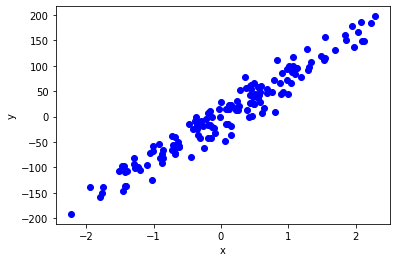

In [ ]:

plt.scatter(x,y,c="b")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Normalisation

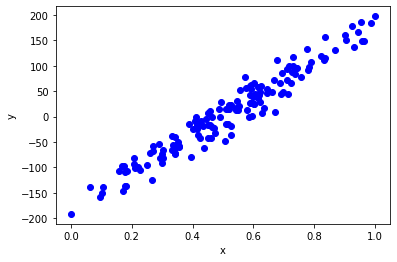

In [ ]:
x=MinMaxScaler().fit_transform(x,y)
plt.scatter(x,y,c="b")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Décomposition de la BD en deux sous-ensembles: Apprentissage et test

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(np.shape(x_train),np.shape(x_test))

(120, 1) (30, 1)


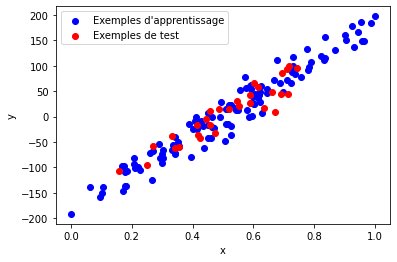

In [ ]:
plt.scatter(x_train,y_train,c='b', label="Exemples d'apprentissage")
plt.scatter(x_test,y_test,c="r",label='Exemples de test')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Modèle KNN

1 :  rmse:  26.337768033644075
2 :  rmse:  25.107594435958994
3 :  rmse:  24.19001788815568
4 :  rmse:  23.000384349832203
5 :  rmse:  22.30654012365797
6 :  rmse:  22.065686356875087
7 :  rmse:  21.201589824903497
8 :  rmse:  20.65186877118189
9 :  rmse:  20.802095259821137
10 :  rmse:  19.9938856509265
11 :  rmse:  20.048708175183695
12 :  rmse:  19.98885886100142
13 :  rmse:  19.632794337255085
14 :  rmse:  19.517436309195972
15 :  rmse:  19.29872291685031
16 :  rmse:  19.316622186463185
17 :  rmse:  19.619286748025168
18 :  rmse:  19.82789646476714
19 :  rmse:  19.85015466780458


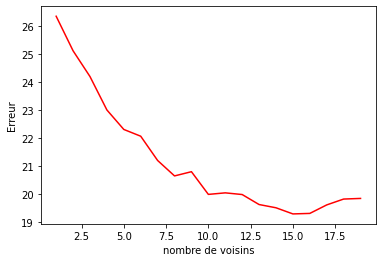

In [ ]:
listErr=[]
n_neighbors=range(1,20)

for k in n_neighbors:
  knn=KNeighborsRegressor(n_neighbors=k, metric="euclidean")

  knn.fit(x_train,y_train)
  y_pred=knn.predict(x_test)
  test_mse = mean_squared_error(y_test, y_pred)
  test_rmse = sqrt(test_mse)

  print(k,":"," rmse: ",test_rmse)

  listErr.append(test_rmse)

plt.plot(n_neighbors,listErr, c="r")
plt.xlabel("nombre de voisins")
plt.ylabel("Erreur")
plt.show()



Le choix du meilleur nombre de nombre

In [ ]:
erreurMin=np.min(listErr)
print("l'erreur min est:", erreurMin)
nbVoisinOptimal=np.argmin(listErr)+1
print("le nombre de voisin optimal est: ",nbVoisinOptimal )

l'erreur min est: 19.29872291685031
le nombre de voisin optimal est:  15


In [ ]:
knn=KNeighborsRegressor(n_neighbors=nbVoisinOptimal, metric="euclidean")
knn.fit(x_train,y_train)
y_pred=knn.predict(x_train)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
print(rmse)

20.511193286526385


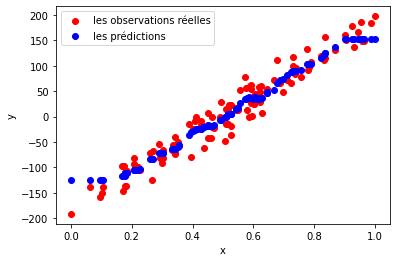

In [ ]:
knn=KNeighborsRegressor(n_neighbors=nbVoisinOptimal, metric="euclidean")
knn.fit(x_train,y_train)
y_pred=knn.predict(x_train)

plt.scatter(x_train,y_train,c="r",label="les observations réelles")
plt.scatter(x_train,y_pred,c="b",label="les prédictions")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


Méthode 2 avec grif search

In [ ]:
from sklearn.model_selection import GridSearchCV
parameters = {"n_neighbors": n_neighbors,"metric":["euclidean","manhattan","minkowski"]}#,"weights": ["uniform", "distance"]}
gridsearch = GridSearchCV(KNeighborsRegressor(), parameters)
gridsearch.fit(x_train, y_train)

GridSearchCV(estimator=KNeighborsRegressor(),
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': range(1, 20)})

In [ ]:
print(gridsearch.best_params_)

{'metric': 'euclidean', 'n_neighbors': 13}


In [ ]:
best_k = gridsearch.best_params_["n_neighbors"]
best_distance = gridsearch.best_params_["metric"]

grid_knn = KNeighborsRegressor( n_neighbors=best_k, metric=best_distance)
grid_knn.fit(x_train, y_train)
train_preds_grid = grid_knn.predict(x_train)
train_mse = mean_squared_error(y_train, train_preds_grid)
train_rmse = np.sqrt(train_mse)
print(train_rmse)

20.511193286526385


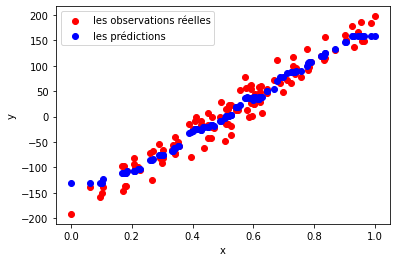

In [ ]:
plt.scatter(x_train,y_train,c="r",label="les observations réelles")
plt.scatter(x_train,train_preds_grid,c="b",label="les prédictions")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


# **Evaluation**

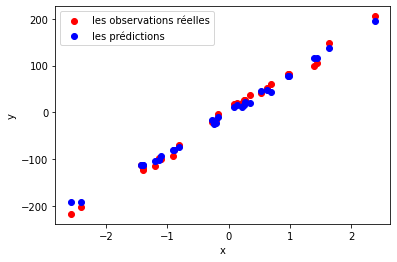

In [ ]:
knn=KNeighborsRegressor(n_neighbors=nbVoisinOptimal, metric="euclidean")
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)

plt.scatter(x_test,y_test,c="r",label="les observations réelles")
plt.scatter(x_test,y_pred,c="b",label="les prédictions")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

plt.show()


In [ ]:
knn.n_neighbors

4

In [ ]:
y_pred=knn.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(rmse)


10.013579612284458
